# Binary Fault Classification — Physics-Weight Loss

This notebook trains the binary classifier with this project's own physics-consistency **loss term** enabled: `CrossEntropyLoss + physics_weight * MSE(probabilities, physics_targets)` (see `model.py`'s `PhysicsInformedNN`, `use_physics_loss=True`). It uses the same Paderborn windows, engineered features (`PhysicsFeatureExtractor`), grouped split, and class weighting as `Binary_Classification_Baseline.ipynb` — the controlled difference is `use_physics_loss=True` vs. `False`.

**This notebook does NOT implement the reference paper's algorithm.** The paper (Li et al., EUSIPCO 2025) never uses a physics loss term at all — its "physics-informed" contribution is a frequency-bin *feature selection* step ("Algorithm 1"), implemented separately in `paper_features.py` (`PaperFeatureSelector`) and exercised by `Binary_Classification_PINN_Algo.ipynb`. This notebook was previously misnamed `Binary_Classification_PINN_Algo.ipynb`; it was renamed to avoid that confusion.

In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [38]:
!mkdir -p /kaggle/working/repo
!cp -r "/kaggle/input/datasets/anaranyosarkar27/pinn-motor-fault-code/induction-motor-fault-classification-via-PINN" /kaggle/working/repo/project
!ls /kaggle/working/repo/project

 5-aug-file.txt					 reports
 context.md					 scripts
 induction-motor-fault-classification-via-PINN	 src
 models						 temp_model.npz
'Progress Report BTech Project (old).pdf'	 temp_results
 pyproject.toml					 tests
 README.md


In [39]:
!pip install -e /kaggle/working/repo/project --break-system-packages -q

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for pinn-motor-fault (pyproject.toml) ... done


In [40]:
!pip show pinn-motor-fault

Name: pinn-motor-fault
Version: 0.1.0
Summary: Physics-informed neural fault classification on the Paderborn University bearing dataset.
Home-page: 
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Editable project location: /kaggle/working/repo/project
Requires: numpy
Required-by: 


In [41]:
import sys
sys.path.insert(0, "/kaggle/working/repo/project/src")
import pinn_motor_fault
print("ok")

ok


In [42]:
from pinn_motor_fault.paderborn import infer_label_from_path, DatasetError
from pathlib import Path

data_dir = Path("/kaggle/input/datasets/dippatel03/paderborn-db")
mat_files = sorted(data_dir.rglob("*.mat"))
print(f"{len(mat_files)} .mat files found")

ok, bad = 0, []
for f in mat_files:
    try:
        infer_label_from_path(f)
        ok += 1
    except DatasetError:
        bad.append(f)
print(f"labeled ok: {ok}, failed: {len(bad)}")

2560 .mat files found
labeled ok: 2560, failed: 0


In [43]:
from collections import Counter
import matplotlib.pyplot as plt
from pathlib import Path
from pinn_motor_fault.paderborn import infer_label_from_path

data_dir = Path("/kaggle/input/datasets/dippatel03/paderborn-db")
mat_files = sorted(data_dir.rglob("*.mat"))
labels = [infer_label_from_path(f) for f in mat_files]
counts = Counter(labels)
print(counts)

Counter({'outer_race': 960, 'inner_race': 880, 'healthy': 480, 'rolling_element': 240})


In [44]:
imbalance_ratio = max(counts.values()) / min(counts.values())
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")
for label, count in sorted(counts.items(), key=lambda x: -x[1]):
    pct = 100 * count / sum(counts.values())
    print(f"  {label:20s} {count:5d} files  ({pct:.1f}%)")

Imbalance ratio (majority/minority): 4.00
  outer_race             960 files  (37.5%)
  inner_race             880 files  (34.4%)
  healthy                480 files  (18.8%)
  rolling_element        240 files  (9.4%)


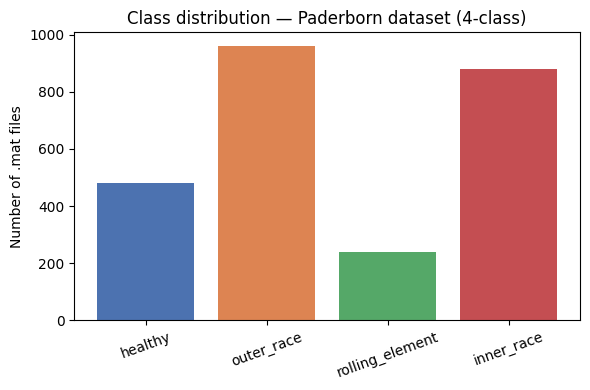

In [45]:
plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values(), color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.ylabel("Number of .mat files")
plt.title("Class distribution — Paderborn dataset (4-class)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("/kaggle/working/class_distribution.png", dpi=150)
plt.show()

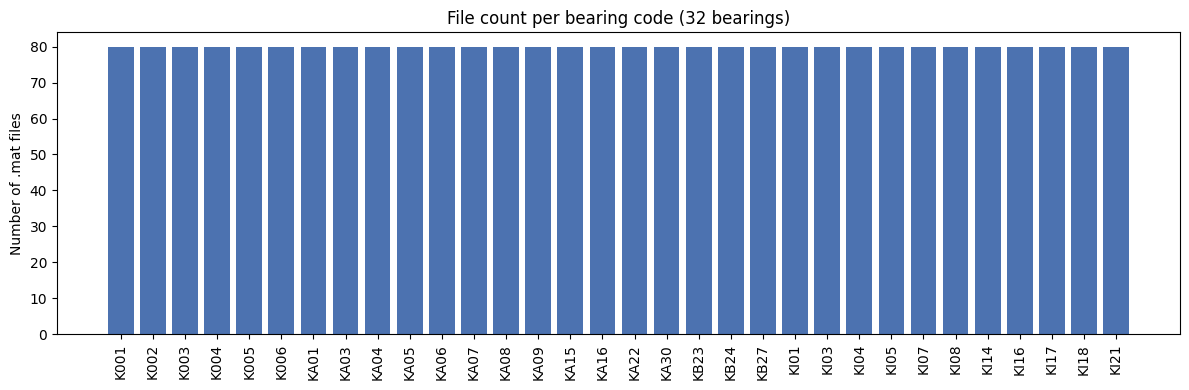

In [46]:
bearing_codes = [f.parent.name for f in mat_files]
code_counts = Counter(bearing_codes)

plt.figure(figsize=(12,4))
plt.bar(code_counts.keys(), code_counts.values(), color='#4C72B0')
plt.xticks(rotation=90)
plt.ylabel("Number of .mat files")
plt.title("File count per bearing code (32 bearings)")
plt.tight_layout()
plt.savefig("/kaggle/working/bearing_code_distribution.png", dpi=150)
plt.show()

In [ ]:
from pathlib import Path

from pinn_motor_fault.fast_train import compute_class_weights, fast_fit
from pinn_motor_fault.features import PhysicsFeatureExtractor
from pinn_motor_fault.model import PhysicsInformedNN
from pinn_motor_fault.paderborn import load_paderborn_windows
from pinn_motor_fault.results import write_evaluation_artifacts
from pinn_motor_fault.train import stratified_group_split

DATA_DIR = Path("/kaggle/input/datasets/dippatel03/paderborn-db")
MODEL_PATH = Path("/kaggle/working/models/paderborn_binary_pinn.npz")
RESULTS_DIR = Path("/kaggle/working/reports/results_binary")
BINARY_CLASS_NAMES = ("healthy", "faulty")

# Load the same grouped Paderborn windows used by the binary baseline.
windows, original_labels, sources = load_paderborn_windows(
    data_dir=DATA_DIR,
    window_size=4096,
    stride=2048,
    signal_preference="vibration",
    max_windows_per_file=30,
)

# Collapse inner-race, outer-race, and rolling-element faults into one class.
labels = np.where(original_labels == "healthy", "healthy", "faulty")
print("Original labels:", dict(zip(*np.unique(original_labels, return_counts=True))))
print("Binary labels:", dict(zip(*np.unique(labels, return_counts=True))))

batch = PhysicsFeatureExtractor().transform(windows, sources)
binary_physics_targets = np.column_stack([
    batch.physics_targets[:, 0],
    batch.physics_targets[:, 1:].sum(axis=1),
])
assert np.allclose(binary_physics_targets.sum(axis=1), 1.0)

train_idx, test_idx = stratified_group_split(
    labels, sources, test_fraction=0.25, seed=17
)
binary_class_weights = compute_class_weights(labels[train_idx], BINARY_CLASS_NAMES)
feature_names = batch.feature_names
print(f"Using {batch.features.shape[1]} original engineered features")
print("Train/test windows:", train_idx.size, test_idx.size)
print("Class weights:", binary_class_weights)

# Physics-weight loss: this project's own physics-consistency loss term
# (CrossEntropy + physics_weight * MSE against physics_targets), NOT the
# reference paper's Algorithm 1 feature-selection method (that is a
# separate, unrelated mechanism implemented in paper_features.py /
# PaperFeatureSelector, exercised by Binary_Classification_PINN_Algo.ipynb).
model = PhysicsInformedNN(
    input_dim=batch.features.shape[1],
    hidden_dim=48,
    physics_weight=0.1,
    learning_rate=0.1,
    use_physics_loss=True,
    class_names=BINARY_CLASS_NAMES,
)
history = fast_fit(
    model,
    batch.features[train_idx],
    labels[train_idx],
    binary_physics_targets[train_idx],
    batch.features[test_idx],
    labels[test_idx],
    binary_physics_targets[test_idx],
    epochs=60,
    batch_size=64,
    class_weights=binary_class_weights,
)
model.save(MODEL_PATH)

test_predictions = model.predict(batch.features[test_idx])
test_probabilities = model.predict_proba(batch.features[test_idx])
train_loss, train_accuracy = model.loss_and_accuracy(
    batch.features[train_idx], labels[train_idx], binary_physics_targets[train_idx]
)
test_loss, test_accuracy = model.loss_and_accuracy(
    batch.features[test_idx], labels[test_idx], binary_physics_targets[test_idx]
)
settings = {
    "model_path": str(MODEL_PATH),
    "data_dir": str(DATA_DIR),
    "sample_count": int(test_idx.size),
    "train_sample_count": int(train_idx.size),
    "test_sample_count": int(test_idx.size),
    "unique_train_files": int(len(set(sources[index] for index in train_idx))),
    "unique_test_files": int(len(set(sources[index] for index in test_idx))),
    "window_size": 4096,
    "stride": 2048,
    "signal": "vibration",
    "split_strategy": "stratified_group_by_mat_file",
    "feature_set": "PhysicsFeatureExtractor original engineered features",
    "algorithm": "binary physics-weight-loss classifier",
    "use_physics_loss": True,
    "epochs": 60,
    "max_windows_per_file": 30,
    "physics_weight": 0.1,
    "learning_rate": 0.1,
    "train_loss": float(train_loss),
    "test_loss": float(test_loss),
    "class_weights": binary_class_weights,
}
metrics = write_evaluation_artifacts(
    output_dir=RESULTS_DIR,
    labels=labels[test_idx],
    predictions=test_predictions,
    probabilities=test_probabilities,
    sources=[sources[index] for index in test_idx],
    model=model,
    feature_names=feature_names,
    windows=windows[test_idx],
    signal_name="vibration",
    settings=settings,
    training_history=history,
)

test_X = batch.features[test_idx]
test_y = labels[test_idx]
results_dir = str(RESULTS_DIR)
print(f"Physics-weight test accuracy: {test_accuracy:.4f}")
print(f"Saved model: {MODEL_PATH}")
print(f"Saved results: {RESULTS_DIR}")

In [ ]:
# SHAP feature importance for the predicted faulty probability.
%pip install shap -q
import shap

background_size = min(50, len(train_idx))
explain_size = min(100, len(test_X))
background = batch.features[train_idx[:background_size]]
explain_X = test_X[:explain_size]

def predict_faulty_probability(values):
    values = np.asarray(values, dtype=np.float64)
    return model.predict_proba(values)[:, 1]

explainer = shap.Explainer(
    predict_faulty_probability,
    background,
    feature_names=feature_names,
)
shap_explanation = explainer(explain_X)
shap_values = np.asarray(shap_explanation.values)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.mean(np.abs(shap_values), axis=0),
}).sort_values("mean_abs_shap", ascending=False)
print(shap_importance.head(20))
shap_importance.to_csv(f"{results_dir}/shap_feature_importance.csv", index=False)

shap.summary_plot(
    shap_values,
    explain_X,
    feature_names=feature_names,
    show=False,
    max_display=20,
)
plt.tight_layout()
plt.savefig(f"{results_dir}/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import json
cm_v2 = pd.read_csv(f"{results_dir}/confusion_matrix.csv", index_col=0)
print(cm_v2)

metrics_v2 = json.load(open(f"{results_dir}/metrics.json"))
print(json.dumps(metrics_v2["class_metrics"], indent=2))

In [ ]:
probabilities = model.predict_proba(test_X)
class_index = {name: i for i, name in enumerate(model.class_names)}
true_class_idx = np.array([class_index[label] for label in test_y])
per_sample_loss = -np.log(probabilities[np.arange(len(test_y)), true_class_idx] + 1e-12)
print(f"mean loss: {per_sample_loss.mean():.4f}  (should roughly match baseline_loss)")

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_vs_feature(feature_name, n_bins=10):
    idx = feature_names.index(feature_name)
    values = test_X[:, idx]
    bin_edges = np.quantile(values, np.linspace(0, 1, n_bins + 1))
    bin_edges[-1] += 1e-9
    bin_ids = np.digitize(values, bin_edges[1:-1])

    bin_centers = []
    bin_losses = []
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        bin_centers.append(values[mask].mean())
        bin_losses.append(per_sample_loss[mask].mean())

    plt.plot(bin_centers, bin_losses, marker='o')
    plt.xlabel(f"{feature_name} (standardized value)")
    plt.ylabel("Mean loss")
    plt.title(f"Loss vs {feature_name}")

In [ ]:
import pandas as pd

fi = pd.read_csv(f"{results_dir}/feature_importance.csv")
top_features = fi.sort_values("importance", ascending=False)["feature"].head(10).tolist()
print("Plotting:", top_features)

fig, axes = plt.subplots(2, 5, figsize=(15, 8))
for ax, feature_name in zip(axes.flat, top_features):
    plt.sca(ax)
    plot_loss_vs_feature(feature_name)
plt.tight_layout()
plt.savefig("/kaggle/working/loss_vs_feature_binary.png", dpi=150)
plt.show()

In [ ]:
display(SVG(f"{results_dir}/figures/training_curves.svg"))

In [ ]:
display(SVG(f"{results_dir}/figures/confusion_matrix.svg"))

In [ ]:
metrics = json.load(open(f"{results_dir}/metrics.json"))
print(f"Overall accuracy: {metrics['accuracy']:.4f}")
print(f"\nClass distribution: {metrics['class_distribution']}")
print(f"\nHyperparameters: {json.dumps(metrics['hyperparameters'], indent=2)}")

In [ ]:
class_metrics_df = pd.DataFrame(metrics["class_metrics"]).T
print(class_metrics_df.round(4))